In [1]:

import zarr
from pathlib import Path

import geopandas as gpd
import pandas as pd

import json
from pathlib import Path

import geopandas as gpd
import os
os.environ["FASTFUELS_API_KEY"] = "test-api-key"

from fastfuels_sdk import (
    Domain,
    Grids,
    Inventories,
    TreeGridBuilder,
)

from shapely.geometry import box
import matplotlib.pyplot as plt
import zipfile

import numpy as np
import copy

In [2]:
# Paths
DATA_DIR = '/Users/leticia/Documents/OCT_2025/Mac_GUI/projects/puc_test/'
boundary = gpd.read_file(DATA_DIR + 'ff_domain.geojson')


In [5]:
import os

os.environ["FASTFUELS_API_KEY"] = "test-api-key"

# ── Domain ───────────────────────────────────────────────────────────────────
print("Creating domain...")
domain = Domain.from_geodataframe(
    geodataframe=boundary,
    name="innovation factory",
    description="innovation factory default FF",
    horizontal_resolution=2.0,
    vertical_resolution=1.0,
)
domain_id = domain.id
print(f"Domain: {domain.name} ({domain_id})")

# ── Tree Inventory ───────────────────────────────────────────────────────────
tree_inventory = Inventories.from_domain_id(domain_id).create_tree_inventory_from_treemap()
tree_inventory = tree_inventory.wait_until_completed(verbose=False)
print(f"Tree inventory status: {tree_inventory.status}")

# ── Tree Inventory Export ────────────────────────────────────────────────────
print("\nExporting FastFuels Trees to geojson...")
tree_inventory_export = tree_inventory.create_export("geojson")
tree_inventory_export = tree_inventory_export.wait_until_completed(verbose=False, in_place=True)
tree_inventory_export.to_file(DATA_DIR + "fastfuels_tree_inventory.geojson")
print(f"Exported tree inventory to data/fastfuels_tree_inventory.geojson")

# ── Tree Grid ────────────────────────────────────────────────────────────────
print("\nBuilding tree grid...")
tree_grid = (
    TreeGridBuilder(domain_id=domain_id)
    .with_bulk_density_from_tree_inventory()
    .with_spcd_from_tree_inventory()
    .build()
)
tree_grid = tree_grid.wait_until_completed(verbose=False, in_place=True)
print(f"Tree grid status: {tree_grid.status}")

# ── Grid Export ───────────────────────────────────────────────────────────────
print("\nExporting grids to zarr...")
grid_export = Grids.from_domain_id(domain_id).create_export("zarr")
grid_export = grid_export.wait_until_completed(verbose=False, in_place=True)

# Save the data
output_path = DATA_DIR + "canopy_fuel_grid.zip"
grid_export.to_file(str(output_path))
print(f"\nExported to {output_path}")


Creating domain...
Domain: innovation factory (e9fe88b8d0744feba9a13d06a453815a)
Tree inventory status: JobStatus.COMPLETED

Exporting FastFuels Trees to geojson...
Exported tree inventory to data/fastfuels_tree_inventory.geojson

Building tree grid...
Tree grid status: JobStatus.COMPLETED

Exporting grids to zarr...

Exported to /Users/leticia/Documents/OCT_2025/Mac_GUI/projects/puc_test/canopy_fuel_grid.zip


In [6]:
import zarr

z = zarr.open(output_path)
fastfuels_tree_voxelized = z['tree']['bulkDensity'][...]

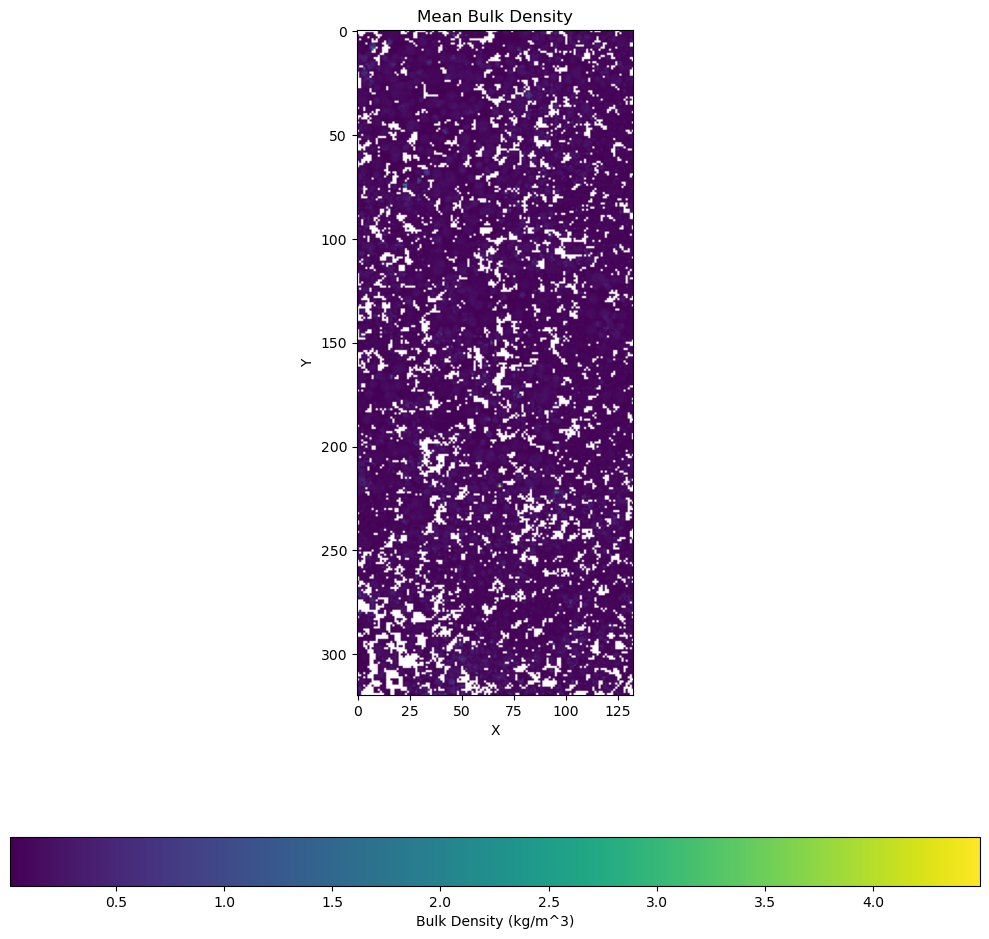

In [13]:
import matplotlib.pyplot as plt
import copy
import numpy as np

data = fastfuels_tree_voxelized
masked_data = np.ma.masked_where(data <= 0.01, data) # Mask all zeros

# masked_data = np.flipud(masked_data)

current_cmap = copy.copy(plt.cm.viridis)
current_cmap.set_bad(color='white')


fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(np.flipud(masked_data.mean(axis=0)), cmap=current_cmap)
ax.set_title("Mean Bulk Density")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.colorbar(im, ax=ax, label="Bulk Density (kg/m^3)", orientation="horizontal")
plt.tight_layout()
plt.show()